<!-- NINO26-CABECALHO v1 -->
# 3K — PCA do bloco de crescimento/acoplamento

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3K`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Reduz o bloco de crescimento ao conjunto mínimo de dimensões físicas independentes — evita tratar variáveis colineares como evidências separadas.

## Pergunta
Qual é o conjunto mínimo indispensável de dimensões físicas independentes que descrevem o crescimento/acoplamento?

## Desafio (hipótese a testar)
PCA de índices escalares não é EOF espacial; a nomenclatura e o número de graus de liberdade efetivos devem ser explícitos.

## Metodologia (com referências)
PCA com scree/biplot e skill LOO nested; graus de liberdade efetivos (Bretherton et al., 1999; Cawley & Talbot, 2010).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3K01", fase=3, bloco="K",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3K_pca_crescimento.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3K01` | `Fig_3K01.png` | `Fig_3K01/` | skill LOO nested |
| `Fig_3K02` | `Fig_3K02.png` | `Fig_3K02/` | scree plot |
| `Fig_3K03` | `Fig_3K03.png` | `Fig_3K03/` | biplot |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

## Contrato científico central

As tabelas abaixo são geradas pelo executor F3 testado. Rótulos de fase/faixa de pico são retrospectivos; previsão usa apenas a tabela rolling-origin. O evento é a unidade independente.


In [1]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
PYTHON = sys.executable
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'smoke')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
assert MODE in {'smoke', 'official'}
print({'root': str(ROOT), 'python': PYTHON, 'mode': MODE, 'run_pipeline': RUN_PIPELINE})

ENSO_TYPE = os.environ.get('NINO26_ENSO_TYPE', '').strip()
assert ENSO_TYPE in {'', 'el_nino', 'la_nina'}
STATS = Path(os.environ.get('NINO26_PHASE3_STATS_DIR', ROOT/'data/processed/parquet/statistics'))


{'root': 'C:\\DEV\\NINO26', 'python': 'C:\\DEV\\NINO26\\.venv\\Scripts\\python.exe', 'mode': 'official', 'run_pipeline': False}


In [2]:
if RUN_PIPELINE:
    command=[PYTHON, str(ROOT/'scripts/phase3_en_ln.py')]
    if ENSO_TYPE: command.extend(['--enso-type', ENSO_TYPE])
    if MODE == 'smoke': command.append('--quick')
    subprocess.run(command, cwd=ROOT, check=True)


,table,exists,manifest
0,phase3_pca_por_fase.csv,True,True
1,phase3_pca_loadings_por_fase.csv,True,True
2,phase3_rolling_origin_folds.csv,True,True


phase3_pca_por_fase.csv


,tipo,fase,componente,var_explicada,var_acumulada,n_eventos_independentes,n_variaveis,evaluation_mode
0,el_nino,crescimento,PC1,0.462237,0.462237,11,31,pca_descritiva_evento_fase
1,el_nino,crescimento,PC2,0.150836,0.613072,11,31,pca_descritiva_evento_fase
2,el_nino,crescimento,PC3,0.131461,0.744534,11,31,pca_descritiva_evento_fase
3,el_nino,crescimento,PC4,0.109995,0.854528,11,31,pca_descritiva_evento_fase
4,el_nino,decaimento,PC1,0.493150,0.493150,11,31,pca_descritiva_evento_fase
5,el_nino,decaimento,PC2,0.241471,0.734620,11,31,pca_descritiva_evento_fase
6,el_nino,decaimento,PC3,0.096557,0.831177,11,31,pca_descritiva_evento_fase
7,el_nino,decaimento,PC4,0.048337,0.879514,11,31,pca_descritiva_evento_fase
8,el_nino,genese,PC1,0.315377,0.315377,12,31,pca_descritiva_evento_fase
9,el_nino,genese,PC2,0.187820,0.503197,12,31,pca_descritiva_evento_fase


phase3_pca_loadings_por_fase.csv


,tipo,fase,variavel,n_eventos_independentes,evaluation_mode,PC1,PC2,PC3,PC4
0,el_nino,crescimento,nino34_ssta,11,pca_descritiva_evento_fase,-0.236413,-0.042032,-0.150237,0.005790
1,el_nino,crescimento,d20_m,11,pca_descritiva_evento_fase,-0.161962,0.312644,-0.018188,0.190841
2,el_nino,crescimento,tilt_m,11,pca_descritiva_evento_fase,-0.214358,-0.035814,0.174739,-0.091482
3,el_nino,crescimento,tilt_slope,11,pca_descritiva_evento_fase,-0.195341,-0.224138,0.167654,-0.034575
4,el_nino,crescimento,ohc_0_100,11,pca_descritiva_evento_fase,-0.242116,-0.091960,-0.093407,-0.009757
5,el_nino,crescimento,ohc_0_300,11,pca_descritiva_evento_fase,-0.227396,0.175770,0.034219,0.143754
6,el_nino,crescimento,ohc_0_700,11,pca_descritiva_evento_fase,-0.229238,0.046504,0.156057,0.140953
7,el_nino,crescimento,ohc_300_700,11,pca_descritiva_evento_fase,-0.095636,-0.267088,0.331586,0.050111
8,el_nino,crescimento,ssh_m,11,pca_descritiva_evento_fase,-0.223080,0.213520,0.011377,0.074382
9,el_nino,crescimento,wwv,11,pca_descritiva_evento_fase,-0.155913,0.168908,0.069153,0.188604


phase3_rolling_origin_folds.csv


,fold_id,test_event_id,train_rows,test_rows,n_train_events,train_event_ids,train_end,test_start,test_end,gap_days,purge_weeks,evaluation_mode,future_events_in_training,test_event_in_training,status
0,rolling_event_01,la_nina_1988_1989,243,91,3,el_nino_1982_1983|la_nina_1983_1984|la_nina_19...,1985-10-27,1987-08-09,1989-04-30,651,78,rolling_origin_evento_agrupado_purgado,False,False,ok
1,rolling_event_02,el_nino_1991_1992,335,70,4,el_nino_1982_1983|el_nino_1986_1988|la_nina_19...,1987-08-02,1990-09-02,1991-12-29,1127,78,rolling_origin_evento_agrupado_purgado,False,False,ok
2,rolling_event_03,el_nino_1994_1995,578,48,6,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1992-03-29,1993-10-03,1994-08-28,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok
3,rolling_event_04,la_nina_1995_1996,626,61,6,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1993-02-28,1994-09-04,1995-10-29,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok
4,rolling_event_05,el_nino_1997_1998,704,74,7,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1994-08-28,1996-06-02,1997-10-26,644,78,rolling_origin_evento_agrupado_purgado,False,False,ok
5,rolling_event_06,la_nina_1998_2001,791,152,8,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1996-04-28,1997-11-02,2000-09-24,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok
6,rolling_event_07,el_nino_2002_2003,869,60,9,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,1997-10-26,2001-07-08,2002-08-25,1351,78,rolling_origin_evento_agrupado_purgado,False,False,ok
7,rolling_event_08,el_nino_2004,1061,48,10,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,2001-07-01,2003-08-03,2004-06-27,763,78,rolling_origin_evento_agrupado_purgado,False,False,ok
8,rolling_event_09,el_nino_2006_2007,1169,48,11,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,2003-07-27,2005-09-04,2006-07-30,770,78,rolling_origin_evento_agrupado_purgado,False,False,ok
9,rolling_event_10,la_nina_2007_2008,1248,74,12,el_nino_1982_1983|el_nino_1986_1988|el_nino_19...,2005-01-30,2006-08-06,2007-12-30,553,78,rolling_origin_evento_agrupado_purgado,False,False,ok


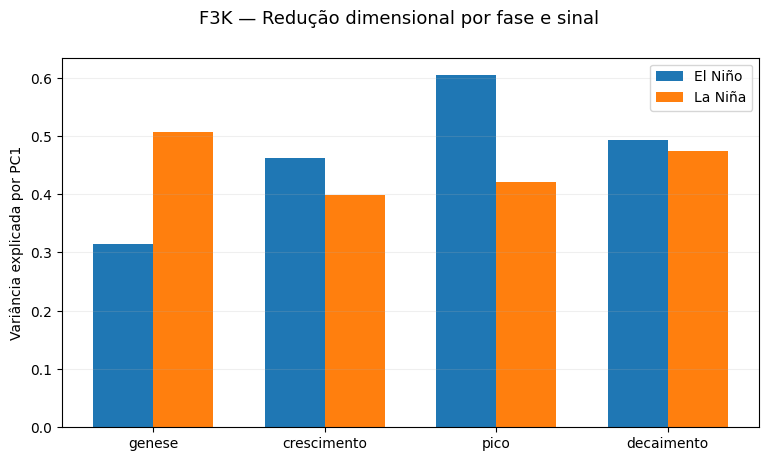

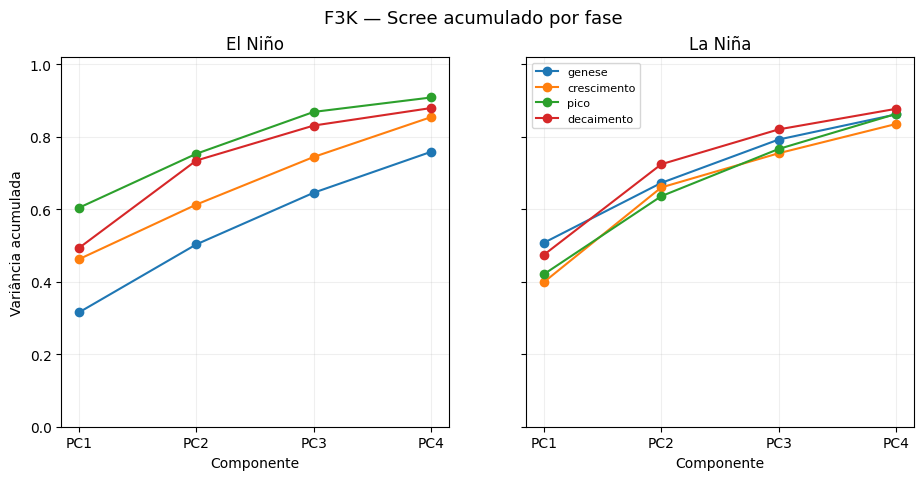

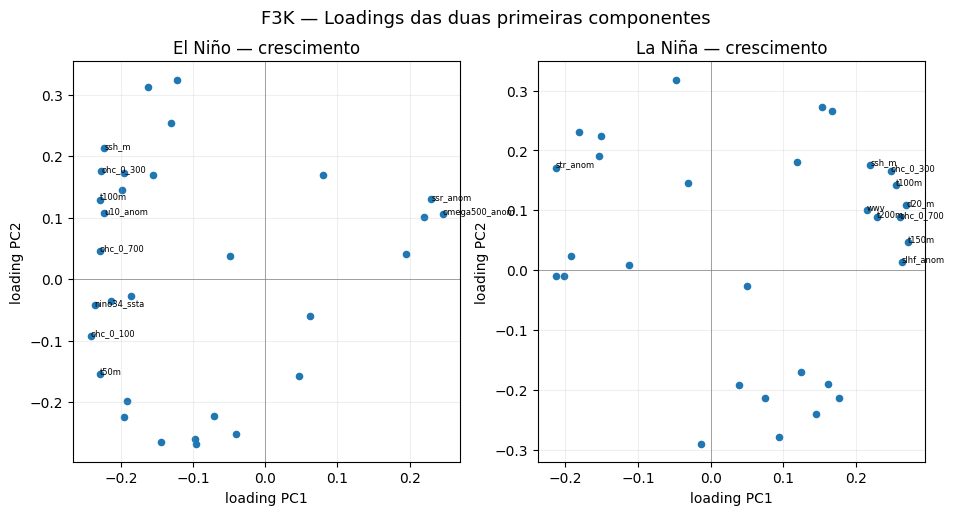

In [3]:
table_names=['phase3_pca_por_fase.csv', 'phase3_pca_loadings_por_fase.csv', 'phase3_rolling_origin_folds.csv']
base = STATS/'pilots/quick' if MODE == 'smoke' else STATS
inventory=[]
for name in table_names:
    path=base/name
    inventory.append({'table':name,'exists':path.exists(),'manifest':path.with_suffix(path.suffix+'.manifest.json').exists()})
display(pd.DataFrame(inventory))
for name in table_names:
    path=base/name
    if path.exists():
        print(name); display(pd.read_csv(path).head(30))

sys.path.insert(0, str(ROOT/'scripts'))
from render_phase3_semantic_summaries import render_block
render_block('K')


## Interpretação permitida

`diagnostico_retrospectivo` descreve gênese/crescimento/faixa de pico/decaimento após o evento. `rolling_origin_operacional` mede previsão. Resultados alinhados ao pico conhecido não são hindcasts operacionais.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Bretherton, C. S., et al. (1999). The Effective Number of Spatial Degrees of Freedom. *J. Climate*, 12, 1990-2009. https://doi.org/10.1175/1520-0442(1999)012<1990:TENOSD>2.0.CO;2
2. Cawley, G. C., & Talbot, N. L. C. (2010). On Over-fitting in Model Selection... *JMLR*, 11, 2079-2107. https://www.jmlr.org/papers/v11/cawley10a.html

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.